In [18]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report
)
from sklearn.inspection import permutation_importance

# Loading in Data
df = pd.read_csv("data/kyle_schwarber_full_data.csv")

df['hits'] = df['events'].isin(['single', 'double', 'triple', 'home_run'])
df['zone'] = df['zone'].astype('category')
df['pitch_number'] = df['pitch_number'].astype('category')
df['pitch_count'] = df['balls'].astype(str) + '-' + df['strikes'].astype(str)

features = [
    "effective_speed",
    "release_spin_rate",
    "pitch_count",
    "p_throws",
    "zone",
    "pitch_number",
    "pitch_name"
]

y = df['hits']
X = pd.get_dummies((df[features]), drop_first=False)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=307, stratify=y)

forest = RandomForestClassifier(n_estimators=500, random_state=307, oob_score=True, n_jobs=-1, class_weight = "balanced")
forest.fit(X_train, y_train)

train_acc = forest.score(X_train, y_train)
oob = forest.oob_score_

y_prob = forest.predict_proba(X_test)[:, 1]

print("Training accuracy: ", train_acc)
print("OOB score: ", oob)
print(y_prob)


Training accuracy:  0.9999042145593869
OOB score:  0.950095785440613
[0.034 0.    0.028 ... 0.122 0.006 0.024]


<BarContainer object of 10 artists>

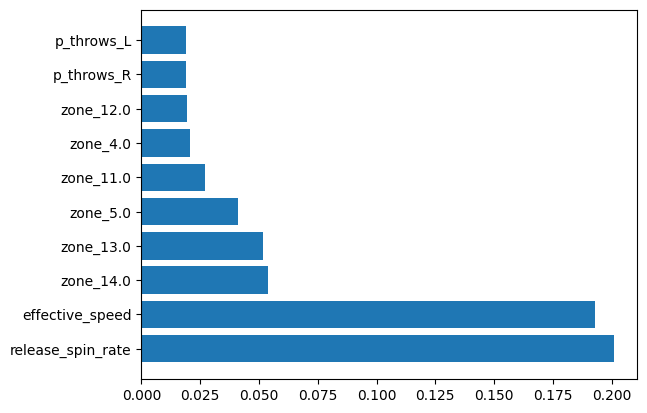

In [19]:
import matplotlib.pyplot as plt

features = forest.feature_importances_
importance_df = pd.DataFrame({
  "feature": X.columns,
  "importance": features
})

importance_df = importance_df.sort_values("importance", ascending=False)

top_10 = importance_df.head(10)

plt.barh(top_10["feature"], top_10["importance"])

In [21]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    forest,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc",
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": X.columns,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

#print(perm_df.head(10))


perm_df = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

perm_df["group"] = perm_df["feature"].str.split("_").str[0]

grouped_perm = (
    perm_df
    .groupby("group")[["importance_mean", "importance_std"]]
    .sum()
    .sort_values("importance_mean", ascending=False)
)

print(grouped_perm)

           importance_mean  importance_std
group                                     
zone              0.185049        0.045767
release          -0.007966        0.006779
p                -0.010565        0.010462
effective        -0.020301        0.009909
pitch            -0.089292        0.084436


In [12]:
from sklearn.metrics import roc_auc_score

print("ROC AUC:", roc_auc_score(y_test, y_prob))

ROC AUC: 0.6679269902412511
